<a href="https://colab.research.google.com/github/LucianoMacias/Aplicacion_Nuevas_Tecnologias-Luciano_Macias/blob/main/tp05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import zipfile

zip_path = "/content/archive.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/dataset")

In [2]:
import os

os.listdir("/content/dataset")

['seg_pred', 'seg_train', 'seg_test']

In [3]:
import os

train_dir = "/content/dataset/seg_train/seg_train"

classes = os.listdir(train_dir)

print(classes)
print("Cantidad de clases:", len(classes))

['sea', 'forest', 'buildings', 'street', 'mountain', 'glacier']
Cantidad de clases: 6


In [4]:
for cls in classes:

    num_images = len(
        os.listdir(
            os.path.join(train_dir, cls)
        )
    )

    print(f"{cls}: {num_images}")

sea: 2274
forest: 2271
buildings: 2191
street: 2382
mountain: 2512
glacier: 2404


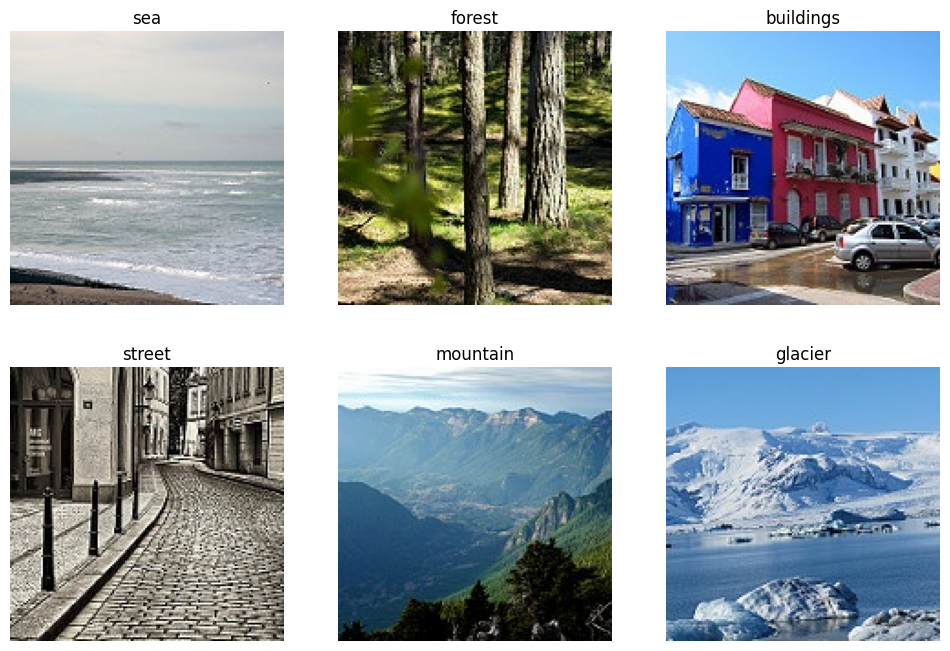

In [5]:
import matplotlib.pyplot as plt
import random

plt.figure(figsize=(12,8))

for i, cls in enumerate(classes):

    img_name = random.choice(
        os.listdir(
            os.path.join(train_dir, cls)
        )
    )

    img_path = os.path.join(
        train_dir,
        cls,
        img_name
    )

    img = plt.imread(img_path)

    plt.subplot(2,3,i+1)

    plt.imshow(img)

    plt.title(cls)

    plt.axis("off")

plt.show()

# Clasificación de Imágenes con CNN y Transfer Learning

## Introducción

La clasificación de imágenes es una de las tareas más importantes dentro del campo de la Visión por Computadora. Su objetivo consiste en asignar una categoría o etiqueta a una imagen a partir de sus características visuales.

En este trabajo se utilizará el dataset **Intel Image Classification**, que contiene imágenes de diferentes escenarios naturales y urbanos. El objetivo es entrenar y comparar dos modelos de clasificación: una red neuronal convolucional (CNN) construida desde cero y un modelo basado en Transfer Learning utilizando una red preentrenada.

---

## Descripción del Dataset

Se utilizó el dataset Intel Image Classification, compuesto por imágenes pertenecientes a seis categorías:

* Sea
* Glacier
* Mountain
* Buildings
* Forest
* Street

Cantidad de imágenes por clase en entrenamiento:

| Clase     | Cantidad |
| --------- | -------: |
| Sea       |     2274 |
| Glacier   |     2404 |
| Mountain  |     2512 |
| Buildings |     2191 |
| Forest    |     2271 |
| Street    |     2382 |

El conjunto de datos presenta una distribución relativamente balanceada entre clases, lo que facilita el entrenamiento de modelos de clasificación sin necesidad de aplicar técnicas especiales de balanceo.


In [6]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [7]:
IMG_SIZE = (150,150)

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.15,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

In [8]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

Found 11932 images belonging to 6 classes.
Found 2102 images belonging to 6 classes.


In [9]:
test_dir = "/content/dataset/seg_test/seg_test"

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 3000 images belonging to 6 classes.


In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

cnn = Sequential([

    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(150,150,3)
    ),

    MaxPooling2D(),

    Conv2D(
        64,
        (3,3),
        activation='relu'
    ),

    MaxPooling2D(),

    Conv2D(
        128,
        (3,3),
        activation='relu'
    ),

    MaxPooling2D(),

    Flatten(),

    Dense(
        128,
        activation='relu'
    ),

    Dropout(0.3),

    Dense(
        6,
        activation='softmax'
    )
])

cnn.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,829,126 (18.42 MB)

 Trainable params: 4,829,126 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
cnn.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [13]:
history_cnn = cnn.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

Epoch 1/10
373/373 ━━━━━━━━━━━━━━━━━━━━ 83s 221ms/step - accuracy: 0.8299 - loss: 0.4682 - val_accuracy: 0.8111 - val_loss: 0.5457
Epoch 2/10
373/373 ━━━━━━━━━━━━━━━━━━━━ 83s 224ms/step - accuracy: 0.8403 - loss: 0.4542 - val_accuracy: 0.8430 - val_loss: 0.4666
Epoch 3/10
373/373 ━━━━━━━━━━━━━━━━━━━━ 83s 222ms/step - accuracy: 0.8342 - loss: 0.4589 - val_accuracy: 0.8183 - val_loss: 0.5133
Epoch 4/10
373/373 ━━━━━━━━━━━━━━━━━━━━ 84s 224ms/step - accuracy: 0.8411 - loss: 0.4439 - val_accuracy: 0.8202 - val_loss: 0.5227
Epoch 5/10
373/373 ━━━━━━━━━━━━━━━━━━━━ 82s 219ms/step - accuracy: 0.8492 - loss: 0.4260 - val_accuracy: 0.8049 - val_loss: 0.5959
Epoch 6/10
373/373 ━━━━━━━━━━━━━━━━━━━━ 83s 222ms/step - accuracy: 0.8544 - loss: 0.4064 - val_accuracy: 0.8454 - val_loss: 0.4753
Epoch 7/10
373/373 ━━━━━━━━━━━━━━━━━━━━ 81s 218ms/step - accuracy: 0.8575 - loss: 0.3989 - val_accuracy: 0.8397 - val_loss: 0.4689
Epoch 8/10
373/373 ━━━━━━━━━━━━━━━━━━━━ 82s 219ms/step - accuracy: 0.8609 - loss: 0

In [17]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(150,150,3)
)

base_model.trainable = False

model_tl = Sequential([
    base_model,
    GlobalAveragePooling2D(),

    Dense(128, activation='relu'),

    Dropout(0.3),

    Dense(6, activation='softmax')
])

/tmp/ipykernel_3519/3793051201.py:5: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


In [18]:
model_tl.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [19]:
history_tl = model_tl.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5
)

Epoch 1/5
373/373 ━━━━━━━━━━━━━━━━━━━━ 127s 293ms/step - accuracy: 0.8131 - loss: 0.5087 - val_accuracy: 0.8801 - val_loss: 0.3324
Epoch 2/5
373/373 ━━━━━━━━━━━━━━━━━━━━ 84s 224ms/step - accuracy: 0.8643 - loss: 0.3702 - val_accuracy: 0.8815 - val_loss: 0.3057
Epoch 3/5
373/373 ━━━━━━━━━━━━━━━━━━━━ 83s 223ms/step - accuracy: 0.8716 - loss: 0.3447 - val_accuracy: 0.8844 - val_loss: 0.3074
Epoch 4/5
373/373 ━━━━━━━━━━━━━━━━━━━━ 84s 226ms/step - accuracy: 0.8768 - loss: 0.3335 - val_accuracy: 0.8849 - val_loss: 0.3074
Epoch 5/5
373/373 ━━━━━━━━━━━━━━━━━━━━ 82s 220ms/step - accuracy: 0.8780 - loss: 0.3241 - val_accuracy: 0.8768 - val_loss: 0.3252


In [20]:
test_loss_tl, test_acc_tl = model_tl.evaluate(
    test_generator
)

print("Test Accuracy:", test_acc_tl)
print("Test Loss:", test_loss_tl)

94/94 ━━━━━━━━━━━━━━━━━━━━ 14s 146ms/step - accuracy: 0.8883 - loss: 0.2805
Test Accuracy: 0.8883333206176758
Test Loss: 0.280464768409729


In [21]:
test_loss_cnn, test_acc_cnn = cnn.evaluate(
    test_generator
)

print("Test Accuracy:", test_acc_cnn)
print("Test Loss:", test_loss_cnn)

94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - accuracy: 0.8577 - loss: 0.4181
Test Accuracy: 0.8576666712760925
Test Loss: 0.4181404113769531


In [22]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

import numpy as np

In [23]:
y_pred = model_tl.predict(test_generator)

y_pred_classes = np.argmax(
    y_pred,
    axis=1
)

y_true = test_generator.classes

94/94 ━━━━━━━━━━━━━━━━━━━━ 13s 89ms/step


In [24]:
print(
    classification_report(
        y_true,
        y_pred_classes,
        target_names=list(
            test_generator.class_indices.keys()
        )
    )
)

              precision    recall  f1-score   support

   buildings       0.89      0.92      0.90       437
      forest       0.97      0.99      0.98       474
     glacier       0.89      0.74      0.81       553
    mountain       0.77      0.86      0.82       525
         sea       0.93      0.94      0.93       510
      street       0.90      0.91      0.91       501

    accuracy                           0.89      3000
   macro avg       0.89      0.89      0.89      3000
weighted avg       0.89      0.89      0.89      3000



In [25]:
cm = confusion_matrix(
    y_true,
    y_pred_classes
)

print(cm)

[[400   1   0   0   0  36]
 [  0 468   0   1   1   4]
 [  1   5 408 115  20   4]
 [  2   7  44 454  15   3]
 [  5   2   6  16 477   4]
 [ 39   1   0   1   2 458]]


## Comparación entre Modelos

Se entrenaron dos enfoques diferentes para resolver el problema de clasificación de imágenes.

El primer enfoque consistió en una red neuronal convolucional (CNN) desarrollada desde cero. Este modelo alcanzó una accuracy de validación de aproximadamente 85.25%.

El segundo enfoque utilizó Transfer Learning mediante MobileNetV2 preentrenada sobre ImageNet. Este modelo alcanzó una accuracy de validación de aproximadamente 87.68%, superando al modelo base.

La mejora obtenida demuestra la utilidad del Transfer Learning cuando se dispone de un conjunto de datos limitado, ya que el modelo puede reutilizar características visuales aprendidas previamente sobre millones de imágenes.

## ¿Detectaron overfitting?

No se observaron señales importantes de overfitting en ninguno de los modelos. Las métricas de entrenamiento y validación permanecieron relativamente cercanas durante todo el proceso de entrenamiento.

## ¿Qué impacto tuvo el data augmentation?

El data augmentation permitió generar variaciones artificiales de las imágenes mediante rotaciones, zoom y flips horizontales. Esto incrementó la diversidad del conjunto de entrenamiento y ayudó a mejorar la capacidad de generalización de los modelos.

## ¿Por qué el Transfer Learning suele funcionar mejor con pocos datos?

Los modelos preentrenados ya han aprendido patrones visuales básicos como bordes, texturas, formas y estructuras complejas a partir de enormes conjuntos de datos. Gracias a ello pueden adaptarse rápidamente a nuevas tareas utilizando una cantidad menor de ejemplos etiquetados.

## ¿Qué revisarían antes de llevar el modelo a producción?

Antes de desplegar el modelo sería necesario evaluar su rendimiento sobre nuevos datos reales, analizar posibles sesgos entre clases, medir tiempos de inferencia, verificar el consumo de recursos y estudiar los errores más frecuentes para garantizar un comportamiento confiable en producción.


# Evaluación en Test

## Resultados Generales

El modelo basado en Transfer Learning (MobileNetV2) obtuvo los siguientes resultados sobre el conjunto de prueba:

* Accuracy: 89%
* Precision promedio: 89%
* Recall promedio: 89%
* F1-Score promedio: 89%

Estos resultados indican que el modelo logra clasificar correctamente la gran mayoría de las imágenes del dataset y presenta un desempeño equilibrado entre precisión y cobertura de las distintas clases.

## Análisis por Clase

| Clase     | Precision | Recall | F1-Score |
| --------- | --------: | -----: | -------: |
| Buildings |      0.89 |   0.92 |     0.90 |
| Forest    |      0.97 |   0.99 |     0.98 |
| Glacier   |      0.89 |   0.74 |     0.81 |
| Mountain  |      0.77 |   0.86 |     0.82 |
| Sea       |      0.93 |   0.94 |     0.93 |
| Street    |      0.90 |   0.91 |     0.91 |

La clase **Forest** fue la mejor clasificada, obteniendo un F1-Score de 0.98. Esto probablemente se debe a que las imágenes de bosques poseen patrones visuales muy distintivos, como vegetación densa y colores predominantes.

Por otro lado, las clases **Glacier** y **Mountain** fueron las más difíciles de clasificar. Esto puede explicarse porque ambas categorías comparten características visuales similares, como nieve, rocas, montañas y paisajes naturales, lo que genera confusiones entre ellas.

## Análisis de Overfitting

No se detectaron señales significativas de overfitting.

En la CNN desarrollada desde cero se obtuvo:

* Accuracy de entrenamiento: 86.46%
* Accuracy de validación: 85.25%

En el modelo MobileNetV2 se obtuvo:

* Accuracy de entrenamiento: 87.80%
* Accuracy de validación: 87.68%

Las diferencias entre entrenamiento y validación fueron pequeñas, indicando una buena capacidad de generalización sobre datos no vistos.

## Impacto del Data Augmentation

El uso de técnicas de data augmentation (rotaciones, zoom y flips horizontales) permitió incrementar artificialmente la variedad de ejemplos de entrenamiento.

Esto ayudó a reducir el riesgo de overfitting y mejoró la capacidad del modelo para reconocer imágenes con pequeñas variaciones de orientación, escala y composición.

## Comparación de Modelos

| Modelo                          | Accuracy Validación |
| ------------------------------- | ------------------: |
| CNN desde cero                  |              85.25% |
| MobileNetV2 (Transfer Learning) |              87.68% |

El modelo basado en Transfer Learning obtuvo mejores resultados que la CNN construida desde cero.

Esto se debe a que MobileNetV2 fue previamente entrenada sobre ImageNet, aprendiendo características visuales generales que pueden reutilizarse para nuevas tareas de clasificación.

## Conclusiones

En este trabajo se implementaron y compararon dos enfoques para la clasificación de imágenes: una red neuronal convolucional desarrollada desde cero y un modelo basado en Transfer Learning.

Los resultados muestran que ambos modelos fueron capaces de clasificar correctamente las imágenes del dataset Intel Image Classification. Sin embargo, MobileNetV2 obtuvo un rendimiento superior, alcanzando aproximadamente un 89% de accuracy y mejores métricas globales.

Además, se comprobó que las técnicas de data augmentation y Transfer Learning permiten mejorar significativamente el rendimiento y la capacidad de generalización de los modelos cuando se dispone de una cantidad limitada de datos.

Finalmente, se observó que las clases con características visuales similares, como Glacier y Mountain, representan el principal desafío para el sistema de clasificación.
